In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, learning_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, fbeta_score, precision_recall_curve, roc_curve
import joblib
import sys
sys.path.append(r"D:\baitaplon\hr-churn-predictor\hr-churn-predictor\backend")
from custom_transformers.lightgbm_transformers import LightGBM_MissingValueHandler, LightGBM_CategoricalTypeCaster, LightGBM_FrequencyEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Tải dữ liệu
file_id = '1e8ImAsI7nDfDyyDCRo6cy2Bde1WEa_mY'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df_raw = pd.read_csv(url)

# Loại bỏ enrollee_id vì không có giá trị dự đoán
df = df_raw.drop(columns=['enrollee_id'])

# Tách feature matrix X và vector nhãn y
X = df.drop(columns=['target'])
y = df['target'].astype(int)

# Train/Test Split 80/20 với stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} mẫu')
print(f'Test set: {X_test.shape[0]} mẫu')

Train set: 15326 mẫu
Test set: 3832 mẫu


In [3]:



# class LightGBM_MissingValueHandler(BaseEstimator, TransformerMixin):
#     # THAY ĐỔI 1: Thêm 'company_size', 'company_type' vào UNKNOWN_COLS
#     UNKNOWN_COLS = ['gender', 'company_size', 'company_type']
#     NO_INFO_COLS = ['major_discipline']
#     MODE_COLS    = ['relevent_experience', 'enrolled_university',
#                     'education_level', 'experience', 'last_new_job']
#     # THAY ĐỔI 2: Thêm MEDIAN_COLS hoàn toàn mới
#     MEDIAN_COLS  = ['city_development_index', 'training_hours']

#     def fit(self, X, y=None):
#         self.modes_ = {
#             col: X[col].mode()[0]
#             for col in self.MODE_COLS if col in X.columns
#         }
#         # THAY ĐỔI 3: Thêm block học median từ tập train
#         self.medians_ = {
#             col: X[col].median()
#             for col in self.MEDIAN_COLS if col in X.columns
#         }
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col in self.UNKNOWN_COLS:
#             if col in X.columns: X[col] = X[col].fillna('Unknown')
#         for col in self.NO_INFO_COLS:
#             if col in X.columns: X[col] = X[col].fillna('No Info')
#         for col, val in self.modes_.items():
#             if col in X.columns: X[col] = X[col].fillna(val)
#         # THAY ĐỔI 4: Thêm block impute median + ép float64
#         for col, val in self.medians_.items():
#             if col in X.columns:
#                 X[col] = X[col].fillna(val)
#                 X[col] = X[col].astype(float)
#         return X


# class LightGBM_CategoricalTypeCaster(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols):
#         self.cat_cols = cat_cols

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col in self.cat_cols:
#             if col in X.columns:
#                 X[col] = X[col].astype('category')
#         return X


# # THAY ĐỔI 5: Thêm class hoàn toàn mới — FrequencyEncoder cho city
# class LightGBM_FrequencyEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, col='city'):
#         self.col = col

#     def fit(self, X, y=None):
#         self.freq_map_ = X[self.col].value_counts(normalize=True).to_dict()
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         X[self.col] = X[self.col].map(self.freq_map_).fillna(0.0)
#         return X

# Liệt kê các biến phân loại (Categorical)
CATEGORICAL_COLS = [ 'gender', 'relevent_experience', 'enrolled_university',
                    'education_level', 'major_discipline', 'experience',
                    'company_size', 'company_type', 'last_new_job']


# Bước 1: Khai báo mô hình kết hợp với pipeline xử lý dữ liệu
full_pipeline_lgbm = Pipeline(steps=[
    ('missing_handler', LightGBM_MissingValueHandler()),
    ('freq_encoder',    LightGBM_FrequencyEncoder(col='city')),
    ('cat_caster', LightGBM_CategoricalTypeCaster(cat_cols=CATEGORICAL_COLS)),
    ('model', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'model__n_estimators': [150, 300],          # Tăng số lượng cây
    'model__learning_rate': [0.01, 0.05],       # Giữ LR nhỏ để học từ từ
    'model__max_depth': [3, 5, 7],
    'model__num_leaves': [7, 15, 31],           # Rất quan trọng! Luôn phải < 2^max_depth
    'model__min_child_samples': [20, 50, 100],  # Bắt buộc mỗi lá phải có ít nhất N mẫu (Rất mạnh để chống nhiễu)
    'model__colsample_bytree': [0.7, 0.9],      # Mỗi cây chỉ được dùng 70%-90% số features (Giảm phụ thuộc vào 1 feature mạnh)
    'model__reg_alpha': [0, 0.1, 1.0],          # Điều chuẩn L1 (Lasso)
    'model__reg_lambda': [0, 0.1, 1.0]          # Điều chuẩn L2 (Ridge)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Khai báo GridSearchCV
grid_search = GridSearchCV(
    estimator=full_pipeline_lgbm,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

# Bước 2: Huấn luyện mô hình và tìm tham số tốt nhất
print("Đang huấn luyện và tìm kiếm siêu tham số tốt nhất...")
grid_search.fit(X_train, y_train)
print("Huấn luyện thành công!")
print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"ROC-AUC tốt nhất trên tập CV: {grid_search.best_score_:.4f}")

# Lấy ra mô hình tốt nhất (best_estimator)
best_model = grid_search.best_estimator_

Đang huấn luyện và tìm kiếm siêu tham số tốt nhất...
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits
[LightGBM] [Info] Number of positive: 3822, number of negative: 11504
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 479
[LightGBM] [Info] Number of data points in the train set: 15326, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Huấn luyện thành công!
Tham số tốt nhất: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__min_child_samples': 20, 'model__n_estimators': 300, 'model__num_leaves': 31, 'model__reg_alpha': 1.0, 'model__reg_lambda': 0.1}
ROC-AUC tốt nhất trên tập CV: 0.8006


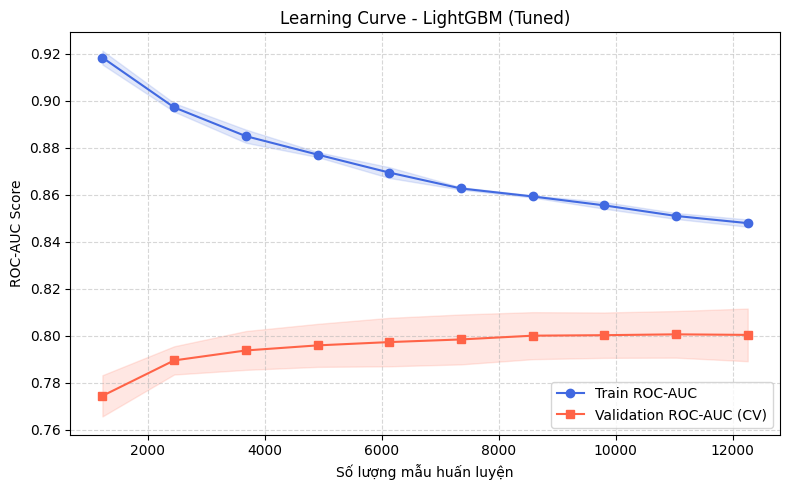

In [4]:
# Bước 3: Vẽ đường cong học tập trên Tập Train
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# Trực quan hóa Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation ROC-AUC (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
plt.title('Learning Curve - LightGBM (Tuned)')
plt.xlabel('Số lượng mẫu huấn luyện')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Bước 4: Tinh chỉnh ngưỡng phân loại (threshold) bằng cross_val_predict trên Tập Train
y_train_pred_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_pred_proba)

# Tìm threshold tối ưu dựa trên chỉ số F2-Score
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-15)
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Ngưỡng tối ưu (Threshold) tìm được: {optimal_threshold:.4f}")
print(f"F2-Score tối ưu trên tập Train: {f2_scores[optimal_idx]:.4f}")

Ngưỡng tối ưu (Threshold) tìm được: 0.3594
F2-Score tối ưu trên tập Train: 0.7003


ROC-AUC: 0.8172
PR-AUC: 0.5587
F2-Score: 0.7226

Báo cáo phân loại (Classification Report) với Threshold tối ưu:
                    precision    recall  f1-score   support

0 - Không tìm việc       0.93      0.69      0.79      2877
 1 - Đang tìm việc       0.47      0.83      0.60       955

          accuracy                           0.72      3832
         macro avg       0.70      0.76      0.70      3832
      weighted avg       0.81      0.72      0.74      3832



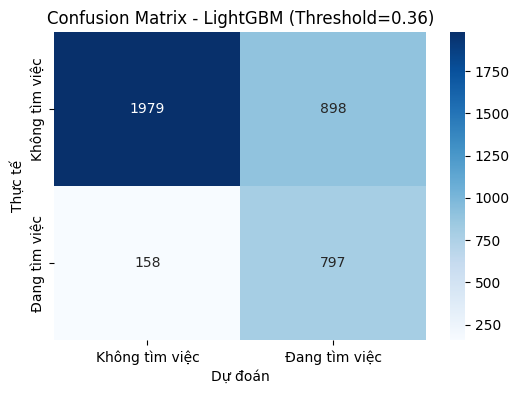

In [6]:
# Bước 5: Dự đoán trên tập Test bằng predict_proba
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Áp dụng threshold tối ưu để sinh nhãn dự đoán cuối cùng
y_test_pred_opt = (y_test_pred_proba >= optimal_threshold).astype(int)

# Đánh giá mô hình
roc_auc = roc_auc_score(y_test, y_test_pred_proba)
pr_auc = average_precision_score(y_test, y_test_pred_proba)
f2_score_val = fbeta_score(y_test, y_test_pred_opt, beta=2)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"F2-Score: {f2_score_val:.4f}\n")
print("Báo cáo phân loại (Classification Report) với Threshold tối ưu:")
print(classification_report(y_test, y_test_pred_opt, target_names=['0 - Không tìm việc', '1 - Đang tìm việc']))

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Không tìm việc', 'Đang tìm việc'], yticklabels=['Không tìm việc', 'Đang tìm việc'])
plt.title(f'Confusion Matrix - LightGBM (Threshold={optimal_threshold:.2f})')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

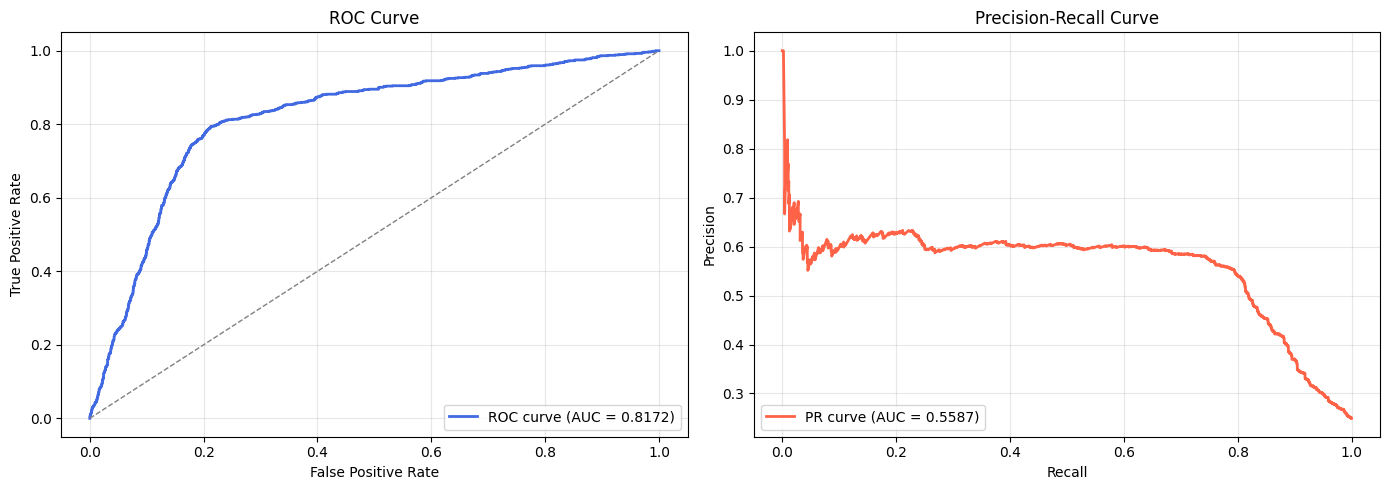

In [7]:
# Bước 6: Vẽ đường cong ROC – AUC, PR – AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[0].plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Đường cong PR
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
axes[1].plot(recall_vals, precision_vals, color='tomato', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

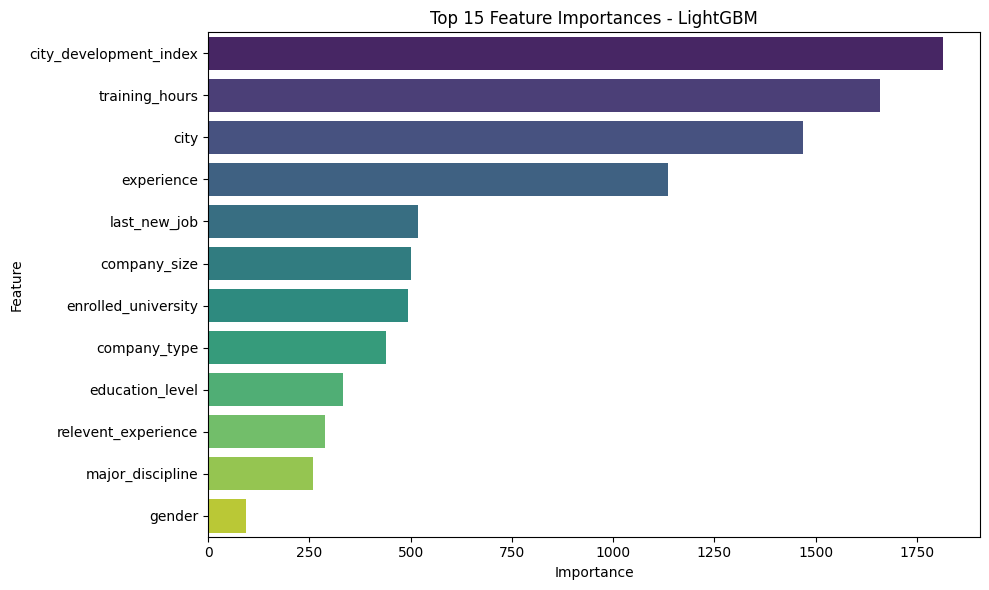

In [8]:
# Bước 7: Trích xuất Feature Important
# Do Pipeline đã bỏ ColumnTransformer, số lượng feature giữ nguyên như bảng X gốc
lgbm_model = best_model.named_steps['model']
feature_names = X_train.columns.tolist()

importances = lgbm_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), palette='viridis')
plt.title('Top 15 Feature Importances - LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [1]:
# Bước 8: Phân tích nguyên nhân mô hình dự đoán sai
df_analyze = X_test.copy()
df_analyze['True_Label'] = y_test
df_analyze['Pred_Label'] = y_test_pred_opt
df_analyze['Pred_Proba'] = y_test_pred_proba

fp_samples = df_analyze[(df_analyze['True_Label'] == 0) & (df_analyze['Pred_Label'] == 1)]
print(f"Số lượng mẫu False Positive (Nhiễu): {len(fp_samples)}")
display(fp_samples.head())

fn_samples = df_analyze[(df_analyze['True_Label'] == 1) & (df_analyze['Pred_Label'] == 0)]
print(f"Số lượng mẫu False Negative (Bỏ sót): {len(fn_samples)}")
display(fn_samples.head())

# Bước 9: Lưu mô hình tốt nhất và ngưỡng threshold
joblib.dump(best_model, 'lightgbm_best_model.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')

print("Đã lưu mô hình tốt nhất tại: lightgbm_best_model.pkl")
print(f"Đã lưu ngưỡng tối ưu ({optimal_threshold:.4f}) tại: optimal_threshold.pkl")

NameError: name 'X_test' is not defined